# Σημασιολογικη τμηματοποιηση Oxford-IIIT Pet με CNN

Αυτο το notebook ειναι ενα project για semantic segmentation στο `data/oxford-iiit-pet`. Ο στοχος ειναι να προβλεφθει μια ετικετα κλασης για καθε pixel σε καθε εικονα, χρησιμοποιωντας μονο οικογενειες συνελικτικων νευρωνικων δικτυων.

Βηματα:

1. Δημιουργια data pipeline για ζευγη εικονας και μασκας trimap.
2. Ορισμος επαναχρησιμοποιησιμων εργαλειων εκπαιδευσης, μετρικων, οπτικοποιησης και grid search.
3. Εκτελεση πρωτα παραλλαγων Fully Convolutional Networks (FCN) ως baseline.
4. Μεταβαση σε U-Net και μετα στην πιο περιπλοκη αρχιτεκτονικη DeepLabv3+.
5. Επιλογη της καλυτερης αρχιτεκτονικης, επανεκπαιδευση της και αξιολογηση στο holdout test split.


## 1. Μεθοδολογια

Semantic segmentation ειναι πιο πυκνο απο classification. Ενας CNN ταξινομησης παραγει μια ετικετα για ολοκληρη την εικονα, ενω ενα CNN τμηματοποιησης παραγει κατανομη κλασεων σε καθε χωρικη θεση.

**Στοχοι.** Το Oxford-IIIT Pet παρεχει μασκες trimap με τρεις τιμες pixel: κατοικιδιο, φοντο και οριο. Αυτο το notebook τις μετατρεπει σε δεικτες κλασεων `0`, `1` και `2`, ωστε να μπορουν να χρησιμοποιηθουν με `nn.CrossEntropyLoss`.

**Εξοδοι μοντελου.** Καθε μοντελο επιστρεφει logits με σχημα `[batch, classes, height, width]`. Οταν ενα μοντελο υπολογιζει χαρακτηριστικα σε χαμηλοτερη χωρικη αναλυση, τα logits μεγεθυνονται ξανα στο μεγεθος της εισοδου με bilinear interpolation.

**Μετρικες.** Η ακριβεια pixel μπορει να φαινεται καλη ακομα και οταν τα ορια ή οι μικρες περιοχες κατοικιδιου ειναι κακες. Η βασικη μετρικη επιλογης ειναι επομενως το mean Intersection over Union (mIoU). Παρακολουθω επισης το mean Dice score και την ακριβεια pixel.

**Grid search.** Η αναζητηση οργανωνεται ανα οικογενεια μοντελων, ωστε τα απλουστερα FCN baselines να δωσουν σημειο αναφορας πριν δοκιμαστουν ισχυροτερες αρχιτεκτονικες. Καθε grid αλλαζει το μεγεθος της αρχιτεκτονικης και, για επιλεγμενες οικογενειες, επιλογες οπως skip connections ή multi-scale pooling widths.


In [5]:
# imports
from pathlib import Path
from collections import OrderedDict
from contextlib import nullcontext
import copy
import itertools
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from torchvision import transforms
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as TF
import pandas as pd
from tqdm.auto import tqdm
from IPython.display import display

from helper import DeepLabV3Plus, DoubleConv, count_parameters, denormalize, set_seed


In [6]:
# Constants and configuration
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data" / "oxford-iiit-pet"
IMAGES_DIR = DATA_ROOT / "images"
ANNOTATIONS_DIR = DATA_ROOT / "annotations"
TRIMAPS_DIR = ANNOTATIONS_DIR / "trimaps"

SEED = 42
IMG_SIZE = 160
BATCH_SIZE = 8
NUM_WORKERS = 0
VAL_FRACTION = 0.15
NUM_CLASSES = 3
CLASS_NAMES = ["pet", "background", "boundary"]

# Μικρες προεπιλογες κανουν το grid search πρακτικο κατα το development.
GRID_SEARCH_MAX_TRAIN_SAMPLES = 1024
GRID_SEARCH_MAX_VAL_SAMPLES = 256
GRID_EPOCHS = 3
FINAL_EPOCHS = 25
MAX_CONFIGS_PER_STAGE = None
TRAIN_BEST_MODEL_AFTER_SEARCH = True

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0
USE_AMP = torch.cuda.is_available()

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Dataset root: {DATA_ROOT}")


Using device: cuda
Dataset root: c:\Users\harpa\Documents\Github\deep-learning-1st-exercise\data\oxford-iiit-pet


## 2. Data pipeline

Το dataset διαβαζεται απο τα split files στα `annotations/trainval.txt` και `annotations/test.txt`.

Το training split δημιουργειται απο το `trainval.txt` με deterministic shuffle. Οι εικονες αλλαζουν μεγεθος με bilinear interpolation, οι μασκες με nearest-neighbor interpolation, και το ιδιο οριζοντιο flip εφαρμοζεται και στην εικονα και στη μασκα. Επισης,  εφαρμοζεται color jitter στην εικονα.


In [7]:
# Helpers
def read_split_file(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            image_id = line.split()[0]
            records.append(image_id)
    return records


def filter_existing_pairs(records, image_dir=IMAGES_DIR, mask_dir=TRIMAPS_DIR):
    valid = []
    missing = []
    for image_id in records:
        image_path = image_dir / f"{image_id}.jpg"
        mask_path = mask_dir / f"{image_id}.png"
        if image_path.exists() and mask_path.exists():
            valid.append(image_id)
        else:
            missing.append(image_id)
    if missing:
        print(f"Skipped {len(missing)} εγγραφες με αρχεια εικονας η μασκας που λειπουν.")
    return valid


def make_pet_splits(val_fraction=VAL_FRACTION, seed=SEED):
    trainval = filter_existing_pairs(read_split_file(ANNOTATIONS_DIR / "trainval.txt"))
    test = filter_existing_pairs(read_split_file(ANNOTATIONS_DIR / "test.txt"))

    rng = random.Random(seed)
    shuffled = trainval[:]
    rng.shuffle(shuffled)
    val_count = max(1, int(len(shuffled) * val_fraction))
    val_records = shuffled[:val_count]
    train_records = shuffled[val_count:]
    return train_records, val_records, test


def take_subset(records, max_items=None, seed=SEED):
    if max_items is None or max_items >= len(records):
        return records
    rng = random.Random(seed)
    sampled = records[:]
    rng.shuffle(sampled)
    return sampled[:max_items]


In [8]:
set_seed()
train_records, val_records, test_records = make_pet_splits()
search_train_records = take_subset(train_records, GRID_SEARCH_MAX_TRAIN_SAMPLES, SEED)
search_val_records = take_subset(val_records, GRID_SEARCH_MAX_VAL_SAMPLES, SEED)

print(f"Train records: {len(train_records)}")
print(f"Validation records: {len(val_records)}")
print(f"Test records: {len(test_records)}")
print(f"Grid-search train records: {len(search_train_records)}")
print(f"Grid-search validation records: {len(search_val_records)}")


Train records: 3128
Validation records: 552
Test records: 3669
Grid-search train records: 1024
Grid-search validation records: 256


In [9]:
class SegmentationPairTransform:
    def __init__(self, image_size=IMG_SIZE, training=False):
        self.image_size = image_size
        self.training = training
        self.color_jitter = transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.03,
        )

    def __call__(self, image, mask):
        image = TF.resize(
            image,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.BILINEAR,
        )
        mask = TF.resize(
            mask,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.NEAREST,
        )

        if self.training and random.random() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        if self.training:
            image = self.color_jitter(image)

        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=MEAN.flatten().tolist(), std=STD.flatten().tolist())

        mask_array = np.asarray(mask, dtype=np.int64)
        # Οι επισημες τιμες trimap ειναι 1=κατοικιδιο, 2=φοντο, 3=οριο.
        # Οι αγνωστες τιμες αντιστοιχιζονται στο φοντο πριν μετατοπιστουν σε ετικετες με βαση το 0.
        mask_array = np.where((mask_array >= 1) & (mask_array <= 3), mask_array, 2)
        mask_tensor = torch.from_numpy(mask_array - 1).long()
        return image, mask_tensor


class OxfordPetSegmentationDataset(Dataset):
    def __init__(self, records, image_dir=IMAGES_DIR, mask_dir=TRIMAPS_DIR, transform=None):
        self.records = list(records)
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        image_id = self.records[index]
        image_path = self.image_dir / f"{image_id}.jpg"
        mask_path = self.mask_dir / f"{image_id}.png"

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path)

        if self.transform is not None:
            image, mask = self.transform(image, mask)
        return image, mask


def make_dataloaders(train_ids, val_ids, test_ids=None, batch_size=BATCH_SIZE):
    train_dataset = OxfordPetSegmentationDataset(
        train_ids,
        transform=SegmentationPairTransform(IMG_SIZE, training=True),
    )
    val_dataset = OxfordPetSegmentationDataset(
        val_ids,
        transform=SegmentationPairTransform(IMG_SIZE, training=False),
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=len(train_dataset) >= batch_size,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    test_loader = None
    if test_ids is not None:
        test_dataset = OxfordPetSegmentationDataset(
            test_ids,
            transform=SegmentationPairTransform(IMG_SIZE, training=False),
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
        )

    return train_loader, val_loader, test_loader




In [10]:
search_train_loader, search_val_loader, _ = make_dataloaders(
    search_train_records,
    search_val_records,
    batch_size=BATCH_SIZE,
)

full_train_loader, full_val_loader, test_loader = make_dataloaders(
    train_records,
    val_records,
    test_records,
    batch_size=BATCH_SIZE,
)

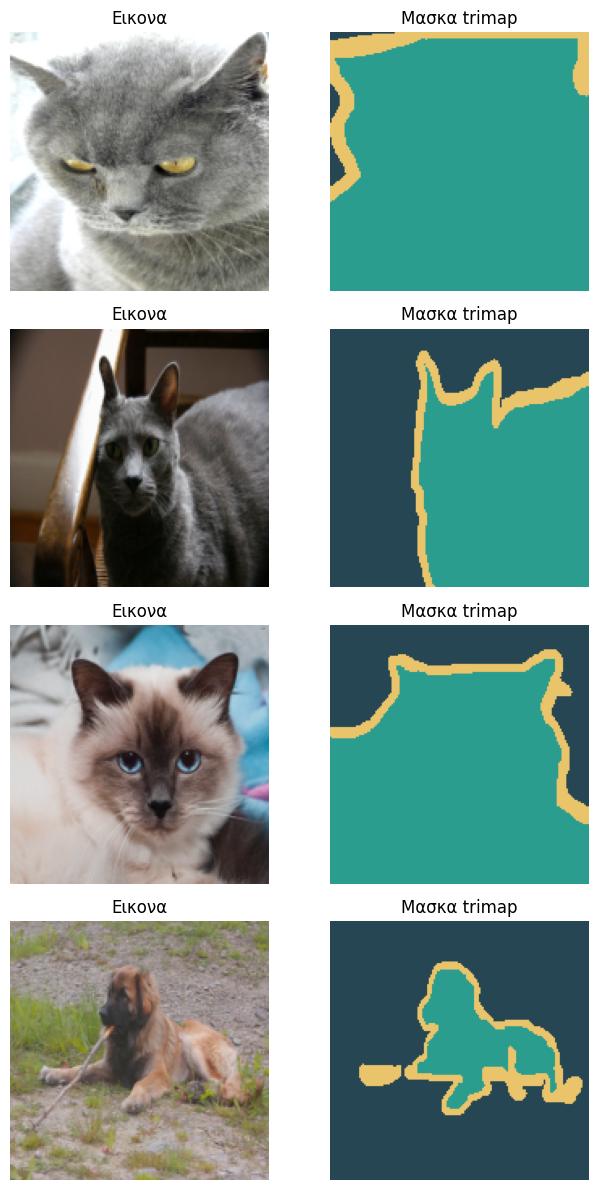

In [ ]:
CLASS_COLORS = torch.tensor(
    [
        [42, 157, 143],   # pet
        [38, 70, 83],     # background
        [233, 196, 106],  # boundary
    ],
    dtype=torch.uint8,
)


def colorize_mask(mask_tensor):
    mask_tensor = mask_tensor.detach().cpu().long()
    return CLASS_COLORS[mask_tensor]


def show_batch(loader, max_items=4):
    images, masks = next(iter(loader))
    max_items = min(max_items, images.size(0))
    fig, axes = plt.subplots(max_items, 2, figsize=(7, 3 * max_items))
    if max_items == 1:
        axes = np.expand_dims(axes, axis=0)
    for i in range(max_items):
        axes[i, 0].imshow(denormalize(images[i]).permute(1, 2, 0))
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(colorize_mask(masks[i]))
        axes[i, 1].set_title("Μασκα trimap")
        axes[i, 1].axis("off")
    plt.tight_layout()


show_batch(search_train_loader, max_items=4)


## 3. Losses, μετρικες και Training Utilities

Οι βασικες Losses ειναι cross entropy και cross-entropy μαζι με soft-Dice.

Η cross entropy ειναι ισχυρη προεπιλογη για multi-class τμηματοποιηση, επειδη καθε pixel αντιμετωπιζεται ως επιβλεπομενο παραδειγμα ταξινομησης. Η Dice loss βελτιστοποιει αμεσα την επικαλυψη και συχνα βελτιωνει μικρες η λεπτες κλασεις, οπως η κλαση οριου. Η hybrid απωλεια κρατα τις σταθερες κλισεις της cross entropy ενω επιβραβευει την επικαλυψη περιοχων.

Ο confusion matrix συσσωρευεται στη CPU για καθε περασμα αξιολογησης. Απο αυτον υπολογιζουμε:

- **Ακριβεια pixel:** ποσοστο σωστα ταξινομημενων pixel.
- **Mean IoU:** μεσος intersection-over-union σε κατοικιδιο, φοντο και οριο.
- **Mean Dice:** μεσος συντελεστης Dice στις ιδιες κλασεις.


Σημειωση:
Σε ιατρικες εικονες, οπως απεικονιση παθολογιας κυτταρων, συνηθως τα ιδια τα κυτταρα καταλαμβανουν το μεγαλυτερο μερος της εικονας. Αν χρησιμοποιηθει IoU Loss, το δικτυο μπορει να επιλεξει να προβλεπει ολοκληρες τις εικονες ως θετικες και παλι να δινει αξιοπρεπη αποδοση, κατι που θα δυσκολευε την περαιτερω μαθηση. Αν χρησιμοποιηθει Dice Loss, αυξανεται το βαρος της επικαλυψης στον ορισμο της απωλειας, οποτε το δικτυο παρακινειται να διαχωριζει τα κυτταρα αντι να μαθαινει ευρετικες οπως στην περιπτωση του IoU Loss.


In [ ]:
def estimate_class_weights(loader, num_classes=NUM_CLASSES):
    counts = torch.zeros(num_classes, dtype=torch.float64)
    for _, masks in tqdm(loader, desc="Εκτιμηση βαρων κλασεων"):
        counts += torch.bincount(masks.view(-1), minlength=num_classes).double()
    frequencies = counts / counts.sum().clamp_min(1)
    weights = 1.0 / torch.log(1.02 + frequencies)
    # print("wei" + str(weights))
    weights = weights / weights.mean()
    # print("wei" + str(weights))
    return weights.float()


class DiceCrossEntropyLoss(nn.Module):
    def __init__(self, weight=None, ce_weight=0.5, dice_weight=0.5, eps=1e-6):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=weight)
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.eps = eps

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        probabilities = torch.softmax(logits, dim=1)
        one_hot = F.one_hot(targets, num_classes=logits.shape[1]).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = torch.sum(probabilities * one_hot, dims)
        cardinality = torch.sum(probabilities + one_hot, dims)
        dice = (2.0 * intersection + self.eps) / (cardinality + self.eps)
        dice_loss = 1.0 - dice.mean()
        return self.ce_weight * ce_loss + self.dice_weight * dice_loss


def make_loss(loss_name="dice_ce", class_weights=None):
    if class_weights is not None:
        class_weights = class_weights.to(DEVICE)
    if loss_name == "ce":
        return nn.CrossEntropyLoss(weight=class_weights)
    if loss_name == "dice_ce":
        return DiceCrossEntropyLoss(weight=class_weights)
    raise ValueError(f"Unknown loss: {loss_name}")


def update_confusion_matrix(confmat, predictions, targets, num_classes=NUM_CLASSES):
    predictions = predictions.detach().view(-1).cpu().long()
    targets = targets.detach().view(-1).cpu().long()
    valid = (targets >= 0) & (targets < num_classes)
    indices = num_classes * targets[valid] + predictions[valid]
    confmat += torch.bincount(indices, minlength=num_classes ** 2).reshape(num_classes, num_classes)
    return confmat


def metrics_from_confusion(confmat):
    confmat = confmat.float()
    true_positive = torch.diag(confmat)
    support = confmat.sum(dim=1)
    predicted = confmat.sum(dim=0)
    union = support + predicted - true_positive

    iou = true_positive / union.clamp_min(1)
    dice = 2 * true_positive / (support + predicted).clamp_min(1)
    accuracy = true_positive.sum() / confmat.sum().clamp_min(1)

    return {
        "pixel_acc": accuracy.item(),
        "mean_iou": iou.mean().item(),
        "mean_dice": dice.mean().item(),
        "class_iou": iou.tolist(),
        "class_dice": dice.tolist(),
    }


def forward_logits(model, images, target_size):
    logits = model(images)
    if logits.shape[-2:] != target_size:
        logits = F.interpolate(logits, size=target_size, mode="bilinear", align_corners=False)
    return logits


def amp_context(enabled=USE_AMP):
    if enabled and torch.cuda.is_available():
        return torch.amp.autocast("cuda")
    return nullcontext()


def train_one_epoch(model, loader, loss_fn, optimizer, scaler=None, device=DEVICE):
    model.train()
    total_loss = 0.0
    confmat = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)

    for images, masks in tqdm(loader, desc="train", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with amp_context(scaler is not None):
            logits = forward_logits(model, images, masks.shape[-2:])
            loss = loss_fn(logits, masks)

        if scaler is not None:
            scaler.scale(loss).backward()
            if GRAD_CLIP_NORM is not None:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            if GRAD_CLIP_NORM is not None:
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        predictions = logits.argmax(dim=1)
        confmat = update_confusion_matrix(confmat, predictions, masks)

    metrics = metrics_from_confusion(confmat)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics


@torch.no_grad()
def evaluate(model, loader, loss_fn, device=DEVICE):
    model.eval()
    total_loss = 0.0
    confmat = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)

    for images, masks in tqdm(loader, desc="eval", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = forward_logits(model, images, masks.shape[-2:])
        loss = loss_fn(logits, masks)

        total_loss += loss.item() * images.size(0)
        predictions = logits.argmax(dim=1)
        confmat = update_confusion_matrix(confmat, predictions, masks)

    metrics = metrics_from_confusion(confmat)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics


def fit_model(model, train_loader, val_loader, loss_fn, optimizer, epochs, scheduler=None, device=DEVICE):
    scaler = torch.amp.GradScaler("cuda") if USE_AMP else None
    history = []
    best = {
        "epoch": None,
        "val_mean_iou": -math.inf,
        "state_dict": copy.deepcopy(model.state_dict()),
    }

    for epoch in range(1, epochs + 1):
        start = time.time()
        train_metrics = train_one_epoch(model, train_loader, loss_fn, optimizer, scaler, device)
        val_metrics = evaluate(model, val_loader, loss_fn, device)
        if scheduler is not None:
            scheduler.step()

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_miou": train_metrics["mean_iou"],
            "train_dice": train_metrics["mean_dice"],
            "val_loss": val_metrics["loss"],
            "val_miou": val_metrics["mean_iou"],
            "val_dice": val_metrics["mean_dice"],
            "val_pixel_acc": val_metrics["pixel_acc"],
            "seconds": time.time() - start,
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {row['train_loss']:.4f} miou {row['train_miou']:.3f} | "
            f"val loss {row['val_loss']:.4f} miou {row['val_miou']:.3f} dice {row['val_dice']:.3f}"
        )

        if val_metrics["mean_iou"] > best["val_mean_iou"]:
            best = {
                "epoch": epoch,
                "val_mean_iou": val_metrics["mean_iou"],
                "val_metrics": val_metrics,
                "state_dict": copy.deepcopy(model.state_dict()),
            }

    model.load_state_dict(best["state_dict"])
    return history, best


search_class_weights = estimate_class_weights(search_train_loader, NUM_CLASSES)
print("Search class weights:", dict(zip(CLASS_NAMES, search_class_weights.tolist())))


Εκτιμηση βαρων κλασεων:   0%|          | 0/128 [00:00<?, ?it/s]

Βαρη κλασεων αναζητησης: {'pet': 0.7930542826652527, 'background': 0.46917110681533813, 'boundary': 1.7377746105194092}


## 4. Οικογενειες αρχιτεκτονικων CNN

Ολα τα μοντελα παρακατω ειναι πληρως συνελικτικα. Δεν χρησιμοποιουν transformer blocks η προεκπαιδευμενους encoders ταξινομησης. Ο σκοπος του grid search ειναι να συγκρινει architectural inductive biases κατω απο κοινο training loop.

### FCN baseline

Ενα Fully Convolutional Network αντικαθιστα τα dense classification heads με συνελικτικα prediction heads. Ειναι το πιο καθαρο baseline τμηματοποιησης, επειδη ρωτα: ποσα μπορει να μαθει ενας απλος encoder μαζι με upsampling; Το no-skip FCN δοκιμαζει τον ακατεργαστο coarse decoder. Η παραλλαγη με skip προσθετει προβλεψεις ρηχων χαρακτηριστικων πισω στη διαδρομη upsampling, ωστε λεπτη χωρικη πληροφορια να επηρεασει την τελικη μασκα.

### U-Net

Το U-Net χρησιμοποιει συμμετρικο encoder-decoder με skip concatenations. Ο encoder μαθαινει σημασιολογικο context, ενω ο decoder επαναφερει προοδευτικα την αναλυση. Η συνενωση χαρακτηριστικων του encoder με τον decoder βοηθα ιδιαιτερα στα ορια αντικειμενων, επειδη τα πρωιμα layers κρατουν τοπικη πληροφορια ακμων και texture information.

### DeepLabv3+

Το DeepLabv3+ συνδυαζει atrous convolution, Atrous Spatial Pyramid Pooling και εναν ελαφρυ decoder. Τα atrous convolutions αυξανουν το receptive field χωρις επιπλεον pooling, ενω το ASPP συλλεγει context σε πολλους dilation rates. Ο decoder συνθετει χαρακτηριστικα ASPP με χαρακτηριστικα χαμηλοτερου επιπεδου για να ανακτησει πιο καθαρες ακμες.


In [13]:
# Τα κοινα συνελικτικα blocks εισαγονται απο το helper.py.

class SimpleEncoder(nn.Module):
    def __init__(self, in_channels=3, channels=(32, 64, 128, 256)):
        super().__init__()
        self.blocks = nn.ModuleList()
        current = in_channels
        for channels_out in channels:
            self.blocks.append(DoubleConv(current, channels_out))
            current = channels_out
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        features = []
        for index, block in enumerate(self.blocks):
            x = block(x)
            features.append(x)
            if index < len(self.blocks) - 1:
                x = self.pool(x)
        return features


In [14]:
class FCNSegmenter(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, channels=(32, 64, 128, 256), use_skips=False, dropout=0.1):
        super().__init__()
        self.encoder = SimpleEncoder(channels=channels)
        self.use_skips = use_skips
        self.head = nn.Sequential(
            nn.Dropout2d(dropout),
            nn.Conv2d(channels[-1], num_classes, kernel_size=1),
        )
        if use_skips:
            self.laterals = nn.ModuleList([nn.Conv2d(ch, num_classes, kernel_size=1) for ch in channels[:-1]])

    def forward(self, x):
        input_size = x.shape[-2:]
        features = self.encoder(x)
        logits = self.head(features[-1])

        if self.use_skips:
            for feature, lateral in reversed(list(zip(features[:-1], self.laterals))):
                logits = F.interpolate(logits, size=feature.shape[-2:], mode="bilinear", align_corners=False)
                logits = logits + lateral(feature)

        return F.interpolate(logits, size=input_size, mode="bilinear", align_corners=False)


class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, channels=(32, 64, 128, 256)):
        super().__init__()
        self.encoder = SimpleEncoder(channels=channels)
        self.decoder = nn.ModuleList(
            [
                UpBlock(channels[index], channels[index - 1], channels[index - 1])
                for index in range(len(channels) - 1, 0, -1)
            ]
        )
        self.classifier = nn.Conv2d(channels[0], num_classes, kernel_size=1)

    def forward(self, x):
        features = self.encoder(x)
        x = features[-1]
        for block, skip in zip(self.decoder, reversed(features[:-1])):
            x = block(x, skip)
        return self.classifier(x)


In [15]:
# Το DeepLabV3Plus εισαγεται απο το helper.py.


In [ ]:
MODEL_REGISTRY = {
    "fcn": FCNSegmenter,
    "unet": UNet,
    "deeplabv3plus": DeepLabV3Plus
}


def build_model(model_name, **model_kwargs):
    if model_name not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model: {model_name}")
    return MODEL_REGISTRY[model_name](num_classes=NUM_CLASSES, **model_kwargs)


@torch.no_grad()
def smoke_test_models(image_size=IMG_SIZE):
    x = torch.randn(2, 3, image_size, image_size)
    rows = []
    for name in MODEL_REGISTRY:
        model = build_model(name)
        y = model(x)
        rows.append(
            {
                "model": name,
                "parameters": count_parameters(model),
                "output_shape": tuple(y.shape),
            }
        )
    return rows


smoke_rows = smoke_test_models()
if pd is not None:
    display(pd.DataFrame(smoke_rows))
else:
    display(smoke_rows)


,model,parameters,output_shape
0,fcn,1173987,"(2, 3, 160, 160)"
1,unet,1927075,"(2, 3, 160, 160)"
2,deeplabv3plus,3741891,"(2, 3, 160, 160)"


## 5. Staged Architecture Grid Search

Καθε σταδιο εχει μια οικογενεια μοντελου, μια συντομη περιγραφη και ενα parameter grid. Το `expand_stage_grid` μετατρεπει καθε σταδιο σε συγκεκριμενες διαμορφωσεις πειραματων, και το `run_grid_search` τις εκπαιδευει με τη σειρα.



In [17]:
GRID_SEARCH_STAGES = [
    {
        "stage": "01_fcn_baseline",
        "model_name": "fcn",
        "grid": OrderedDict(
            channels=[(16, 32, 64, 128), (32, 64, 128, 256)],
            use_skips=[False, True],
            dropout=[0.1],
            lr=[1e-3],
            weight_decay=[1e-4],
            loss_name=["ce", "dice_ce"],
        ),
    },
    {
        "stage": "02_unet",
        "model_name": "unet",
        "grid": OrderedDict(
            channels=[(16, 32, 64, 128), (32, 64, 128, 256)],
            lr=[1e-3],
            weight_decay=[1e-4],
            loss_name=["dice_ce"],
        ),
    },
    {
        "stage": "03_deeplabv3plus",
        "model_name": "deeplabv3plus",
        "grid": OrderedDict(
            base_channels=[16, 24],
            aspp_channels=[64, 96],
            decoder_channels=[96],
            low_channels=[32],
            lr=[1e-3],
            weight_decay=[1e-4],
            loss_name=["dice_ce"],
        ),
    },
]

MODEL_KWARG_EXCLUDE = {"lr", "weight_decay", "loss_name"}


def expand_stage_grid(stage):
    keys = list(stage["grid"].keys())
    values = [stage["grid"][key] for key in keys]
    configs = []
    for combination in itertools.product(*values):
        raw = dict(zip(keys, combination))
        model_kwargs = {key: value for key, value in raw.items() if key not in MODEL_KWARG_EXCLUDE}
        configs.append(
            {
                "stage": stage["stage"],
                "model_name": stage["model_name"],
                "model_kwargs": model_kwargs,
                "lr": raw["lr"],
                "weight_decay": raw["weight_decay"],
                "loss_name": raw["loss_name"],
            }
        )
    if MAX_CONFIGS_PER_STAGE is not None:
        configs = configs[:MAX_CONFIGS_PER_STAGE]
    return configs


def config_name(config):
    parts = [config["stage"], config["model_name"], config["loss_name"]]
    for key, value in config["model_kwargs"].items():
        compact = str(value).replace(" ", "")
        parts.append(f"{key}={compact}")
    return " | ".join(parts)


def all_grid_configs(stages=GRID_SEARCH_STAGES):
    configs = []
    for stage in stages:
        configs.extend(expand_stage_grid(stage))
    return configs


configs_preview = [
    {
        "run": index + 1,
        "stage": config["stage"],
        "model": config["model_name"],
        "params": config["model_kwargs"],
        "loss": config["loss_name"],
        "lr": config["lr"],
    }
    for index, config in enumerate(all_grid_configs())
]

if pd is not None:
    display(pd.DataFrame(configs_preview))
else:
    display(configs_preview)


,run,stage,model,params,loss,lr
0,1,01_fcn_baseline,fcn,"{'channels': (16, 32, 64, 128), 'use_skips': F...",ce,0.001
1,2,01_fcn_baseline,fcn,"{'channels': (16, 32, 64, 128), 'use_skips': F...",dice_ce,0.001
2,3,01_fcn_baseline,fcn,"{'channels': (16, 32, 64, 128), 'use_skips': T...",ce,0.001
3,4,01_fcn_baseline,fcn,"{'channels': (16, 32, 64, 128), 'use_skips': T...",dice_ce,0.001
4,5,01_fcn_baseline,fcn,"{'channels': (32, 64, 128, 256), 'use_skips': ...",ce,0.001
5,6,01_fcn_baseline,fcn,"{'channels': (32, 64, 128, 256), 'use_skips': ...",dice_ce,0.001
6,7,01_fcn_baseline,fcn,"{'channels': (32, 64, 128, 256), 'use_skips': ...",ce,0.001
7,8,01_fcn_baseline,fcn,"{'channels': (32, 64, 128, 256), 'use_skips': ...",dice_ce,0.001
8,9,02_unet,unet,"{'channels': (16, 32, 64, 128)}",dice_ce,0.001
9,10,02_unet,unet,"{'channels': (32, 64, 128, 256)}",dice_ce,0.001


In [ ]:
def run_single_experiment(config, train_loader, val_loader, class_weights, epochs=GRID_EPOCHS, seed=SEED):
    set_seed(seed)
    model = build_model(config["model_name"], **config["model_kwargs"]).to(DEVICE)
    loss_fn = make_loss(config["loss_name"], class_weights=class_weights)
    optimizer = optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs))

    print("\n" + "=" * 90)
    print(config_name(config))
    print(f"Trainable parameters: {count_parameters(model):,}")

    history, best = fit_model(model, train_loader, val_loader, loss_fn, optimizer, epochs, scheduler)
    best_metrics = best["val_metrics"]
    result = {
        "stage": config["stage"],
        "model_name": config["model_name"],
        "run_name": config_name(config),
        "parameters": count_parameters(model),
        "best_epoch": best["epoch"],
        "val_loss": best_metrics["loss"],
        "val_miou": best_metrics["mean_iou"],
        "val_dice": best_metrics["mean_dice"],
        "val_pixel_acc": best_metrics["pixel_acc"],
        "config": copy.deepcopy(config),
    }
    return result, history


def run_grid_search(stages, train_loader, val_loader, class_weights, epochs=GRID_EPOCHS):
    results = []
    histories = {}
    run_index = 0

    for stage in stages:
        stage_configs = expand_stage_grid(stage)
        print(f"\n### Stage {stage['stage']} ({len(stage_configs)} configs) ###")
        for config in stage_configs:
            run_index += 1
            result, history = run_single_experiment(
                config,
                train_loader,
                val_loader,
                class_weights,
                epochs=epochs,
                seed=SEED + run_index,
            )
            results.append(result)
            histories[result["run_name"]] = history
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return results, histories


def results_table(results):
    rows = [{key: value for key, value in result.items() if key != "config"} for result in results]
    rows = sorted(rows, key=lambda row: row["val_miou"], reverse=True)
    if pd is not None:
        return pd.DataFrame(rows)
    return rows


def best_result(results):
    return max(results, key=lambda result: result["val_miou"])


In [ ]:
grid_results, grid_histories = run_grid_search(
    GRID_SEARCH_STAGES,
    search_train_loader,
    search_val_loader,
    search_class_weights,
    epochs=GRID_EPOCHS,
)

grid_summary = results_table(grid_results)
display(grid_summary)

winner = best_result(grid_results)
print("Best validation run:")
print(winner["run_name"])
print(f"mIoU={winner['val_miou']:.4f}, Dice={winner['val_dice']:.4f}, ακριβεια pixel={winner['val_pixel_acc']:.4f}")



### Σταδιο 01_fcn_baseline (8 διαμορφωσεις) ###

01_fcn_baseline | fcn | ce | channels=(16,32,64,128) | use_skips=False | dropout=0.1
Εκπαιδευσιμες παραμετροι: 294,387


εκπαιδευση:   0%|          | 0/128 [00:00<?, ?it/s]

αξιολογηση:   0%|          | 0/32 [00:00<?, ?it/s]

Εποχη 01/3 | απωλεια εκπαιδευσης 0.9635 miou 0.355 | απωλεια επικυρωσης 0.8510 miou 0.433 dice 0.582


εκπαιδευση:   0%|          | 0/128 [00:00<?, ?it/s]

...

εκπαιδευση:   0%|          | 0/128 [00:00<?, ?it/s]

αξιολογηση:   0%|          | 0/32 [00:00<?, ?it/s]

Εποχη 02/3 | απωλεια εκπαιδευσης 0.6219 miou 0.480 | απωλεια επικυρωσης 0.5785 miou 0.508 dice 0.655


εκπαιδευση:   0%|          | 0/128 [00:00<?, ?it/s]

αξιολογηση:   0%|          | 0/32 [00:00<?, ?it/s]

## 6. Εστιασμενη βελτιωση DeepLabv3+

Το πρωτο grid search εντοπιζει την ισχυροτερη γενικη οικογενεια αρχιτεκτονικης. Αυτο το follow-up κρατα την αναζητηση εστιασμενη στο DeepLabv3+ και δοκιμαζει εναν λιγο μεγαλυτερο decoder, πλουσιοτερη low-level προβολη, εναλλακτικους atrous rates και χαμηλοτερα learning rates. Τα αποτελεσματα της βελτιωσης συγχωνευονται με τα αρχικα grid results, οποτε το τελικο βημα επανεκπαιδευσης εξακολουθει να επιλεγει την καλυτερη συνολικη validation run.


In [ ]:
DEEPLAB_REFINEMENT_EPOCHS = max(GRID_EPOCHS, 5)

DEEPLAB_REFINEMENT_STAGES = [
    {
        "stage": "04_deeplabv3plus_refinement",
        "model_name": "deeplabv3plus",
        "grid": OrderedDict(
            base_channels=[24, 32],
            aspp_channels=[96, 128],
            decoder_channels=[128],
            low_channels=[48],
            rates=[(1, 6, 12, 18), (1, 4, 8, 12)],
            lr=[7e-4, 5e-4],
            weight_decay=[1e-4],
            loss_name=["dice_ce"],
        ),
    },
]

deeplab_refinement_results, deeplab_refinement_histories = run_grid_search(
    DEEPLAB_REFINEMENT_STAGES,
    search_train_loader,
    search_val_loader,
    search_class_weights,
    epochs=DEEPLAB_REFINEMENT_EPOCHS,
)

combined_results = grid_results + deeplab_refinement_results
grid_histories.update(deeplab_refinement_histories)
grid_summary = results_table(combined_results)
display(grid_summary)

winner = best_result(combined_results)
print("Καλυτερο validation run μετα τη βελτιωση DeepLabv3+:")
print(winner["run_name"])
print(f"mIoU={winner['val_miou']:.4f}, Dice={winner['val_dice']:.4f}, pixel accuracy={winner['val_pixel_acc']:.4f}")


## 7. Επιθεωρηση καμπυλων αναζητησης

Το επομενο κελι σχεδιαζει το validation mIoU για την καλυτερη run απο καθε οικογενεια αρχιτεκτονικης. Αυτο ειναι χρησιμο, επειδη δυο μοντελα μπορει να τελειωνουν με παρομοια scores αλλα να μαθαινουν με πολυ διαφορετικες ταχυτητες. Αν μια ισχυροτερη αρχιτεκτονικη συνεχιζει να ανεβαινει στο τελος της μικρης αναζητησης, ισως αξιζει περισσοτερες εποχες πριν απορριφθει.


In [ ]:
def plot_best_curves_by_stage(results, histories):
    best_by_stage = {}
    for result in results:
        stage = result["stage"]
        if stage not in best_by_stage or result["val_miou"] > best_by_stage[stage]["val_miou"]:
            best_by_stage[stage] = result

    plt.figure(figsize=(10, 5))
    for stage, result in best_by_stage.items():
        history = histories[result["run_name"]]
        epochs = [row["epoch"] for row in history]
        val_miou = [row["val_miou"] for row in history]
        plt.plot(epochs, val_miou, marker="o", label=stage)

    plt.xlabel("Εποχη")
    plt.ylabel("mIoU επικυρωσης")
    plt.title("Καλυτερη καμπυλη επικυρωσης ανα οικογενεια μοντελων")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


plot_best_curves_by_stage(grid_results, grid_histories)


## 8. Επανεκπαιδευση της καλυτερης διαμορφωσης και αξιολογηση σε test data

Το grid search συνηθως τρεχει με μικροτερα budgets, ωστε να μπορουν να συγκριθουν πολλες επιλογες. Αφου επιλεγει η καλυτερη validation configuration, επανεκπαιδευσε τη με ολο το training split και αξιολογησε μια φορα στο holdout test split. Ετσι το test split μενει καθαρο: δεν χρησιμοποιειται για επιλογη αρχιτεκτονικων η hyperparameters.


In [ ]:
def train_best_configuration(winner, epochs=FINAL_EPOCHS):
    config = winner["config"]
    full_class_weights = estimate_class_weights(full_train_loader, NUM_CLASSES)
    model = build_model(config["model_name"], **config["model_kwargs"]).to(DEVICE)
    loss_fn = make_loss(config["loss_name"], class_weights=full_class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs))

    print("Επανεκπαιδευση της καλυτερης διαμορφωσης στο πληρες training split:")
    print(config_name(config))
    history, best = fit_model(model, full_train_loader, full_val_loader, loss_fn, optimizer, epochs, scheduler)
    test_metrics = evaluate(model, test_loader, loss_fn, DEVICE)
    return model, history, best, test_metrics, full_class_weights


if TRAIN_BEST_MODEL_AFTER_SEARCH:
    best_model, final_history, final_best, test_metrics, full_class_weights = train_best_configuration(winner, FINAL_EPOCHS)
    print("Μετρικες test:")
    print({key: value for key, value in test_metrics.items() if not key.startswith("class_")})
    print("IoU ανα κλαση:", dict(zip(CLASS_NAMES, test_metrics["class_iou"])))
else:
    best_model = None
    final_history = []
    test_metrics = None
    print("Θεσε TRAIN_BEST_MODEL_AFTER_SEARCH=True για επανεκπαιδευση και αξιολογηση του επιλεγμενου μοντελου.")


NameError: name 'FINAL_EPOCHS' is not defined

In [ ]:
def plot_training_history(history, title="Ιστορικο εκπαιδευσης"):
    if not history:
        print("Δεν υπαρχει ιστορικο για σχεδιαση.")
        return

    epochs = [row["epoch"] for row in history]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, [row["train_loss"] for row in history], marker="o", label="εκπαιδευση")
    axes[0].plot(epochs, [row["val_loss"] for row in history], marker="o", label="επικυρωση")
    axes[0].set_title("Απωλεια")
    axes[0].set_xlabel("Εποχη")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, [row["train_miou"] for row in history], marker="o", label="mIoU εκπαιδευσης")
    axes[1].plot(epochs, [row["val_miou"] for row in history], marker="o", label="mIoU επικυρωσης")
    axes[1].set_title("mIoU")
    axes[1].set_xlabel("Εποχη")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_training_history(final_history, "Καμπυλες επανεκπαιδευσης καλυτερου μοντελου")


## 9. Ποιοτικη επιθεωρηση προβλεψεων

Οι μετρικες συνοψιζουν την αποδοση, αλλα τα μοντελα τμηματοποιησης πρεπει να επιθεωρουνται και οπτικα. Η οπτικοποιηση παρακατω δειχνει την εικονα εισοδου, το ground-truth trimap, το predicted trimap και εναν χαρτη λαθων. Τα λαθη στα ορια ειναι συχνα, επειδη η κλαση οριου ειναι λεπτη και ευαισθητη στις annotations, οποτε ελεγξε αν τα λαθη ειναι συστηματικα η μεμονωμενα.


In [ ]:
@torch.no_grad()
def visualize_predictions(model, loader, max_items=4, device=DEVICE):
    if model is None:
        print("Δεν υπαρχει ακομα εκπαιδευμενο μοντελο.")
        return

    model.eval()
    images, masks = next(iter(loader))
    images_device = images.to(device)
    logits = forward_logits(model, images_device, masks.shape[-2:])
    predictions = logits.argmax(dim=1).cpu()

    max_items = min(max_items, images.size(0))
    fig, axes = plt.subplots(max_items, 4, figsize=(14, 3.2 * max_items))
    if max_items == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(max_items):
        error = (predictions[i] != masks[i]).long()
        axes[i, 0].imshow(denormalize(images[i]).permute(1, 2, 0))
        axes[i, 0].set_title("Εικονα")
        axes[i, 1].imshow(colorize_mask(masks[i]))
        axes[i, 1].set_title("Πραγματικη μασκα")
        axes[i, 2].imshow(colorize_mask(predictions[i]))
        axes[i, 2].set_title("Προβλεψη")
        axes[i, 3].imshow(error, cmap="magma")
        axes[i, 3].set_title("Χαρτης λαθων")
        for axis in axes[i]:
            axis.axis("off")

    plt.tight_layout()
    plt.show()


visualize_predictions(best_model, test_loader, max_items=4)


## 10. Αποθηκευση του επιλεγμενου CNN μοντελου τμηματοποιησης

Το checkpoint αποθηκευει την οικογενεια μοντελου, τα ορισματα αρχιτεκτονικης, τα ονοματα κλασεων, το μεγεθος εικονας, τις σταθερες κανονικοποιησης, τις validation metrics και τις test metrics. Ετσι γινεται δυνατη η επαναφορτωση του μοντελου χωρις να χρειαζεται μαντεμα της ακριβους grid-search configuration που το παρηγαγε.


In [ ]:
checkpoint_path = PROJECT_ROOT / "best_pet_segmentation_cnn.pt"

if best_model is not None:
    checkpoint = {
        "model_name": winner["config"]["model_name"],
        "model_kwargs": winner["config"]["model_kwargs"],
        "state_dict": best_model.state_dict(),
        "class_names": CLASS_NAMES,
        "image_size": IMG_SIZE,
        "mean": MEAN.flatten().tolist(),
        "std": STD.flatten().tolist(),
        "validation_metrics": final_best.get("val_metrics", None),
        "test_metrics": test_metrics,
        "grid_winner": winner,
    }
    torch.save(checkpoint, checkpoint_path)
    print(f"Το checkpoint αποθηκευτηκε στο: {checkpoint_path}")
else:
    print("Δεν αποθηκευτηκε checkpoint επειδη δεν εκπαιδευτηκε τελικο μοντελο.")


## 11. Σημειωσεις πειραματος και επομενα βηματα

Χρησιμοποιησε το FCN ως baseline reference. Αν το U-Net ξεπερνα το FCN κυριως στα ορια, τα skip-connections κανουν χρησιμη δουλεια εντοπισμου. Αν το DeepLabv3+ βελτιωνει το mIoU, το multi-scale context βοηθα το μοντελο να συλλογιστει το μεγεθος του κατοικιδιου και τη συνθεση της εικονας. Το εστιασμενο σταδιο βελτιωσης ελεγχει αν ενας λιγο ισχυροτερος decoder DeepLabv3+ και εναλλακτικοι atrous rates μπορουν να βελτιωσουν το πρωτο περασμα DeepLabv3+.

Για ισχυροτερη τελικη εκτελεση:

- Θεσε `GRID_SEARCH_MAX_TRAIN_SAMPLES = None` και `GRID_SEARCH_MAX_VAL_SAMPLES = None`.
- Αυξησε το `GRID_EPOCHS` σε 8-15 και το `FINAL_EPOCHS` σε 25 η περισσοτερο.
- Αυξησε το `DEEPLAB_REFINEMENT_EPOCHS` αν οι refinement curves ακομα βελτιωνονται.
- Αυξησε το `IMG_SIZE` σε 224 αν το επιτρεπει η μνημη.
- Συγκρινε per-class IoU, οχι μονο συνολικο mIoU, επειδη η αποδοση στα ορια μπορει να κινειται διαφορετικα απο την αποδοση σε κατοικιδιο/φοντο.
